In [1]:
import matplotlib.pyplot as plt
from statsmodels.base.model import GenericLikelihoodModel
import numpy as np
import cv2
import scienceplots
import tifffile as tiff

from boulder_statistics.analysis.data_product_encyclopedia import DataProductEncyclopedia
from boulder_statistics.analysis.fit_params.power_law_fit_params import PowerLawFitParams
plt.style.use('science')
plt.rcParams["figure.figsize"] = (3.5, 3.5 * ((5**0.5 - 1) / 2)) # 3.5
plt.rcParams["figure.dpi"] = 600
%matplotlib inline

import polars as pl
from polars import Expr, LazyFrame, DataFrame
import numpy as np
from pathlib import Path
from typing import Any
import tifffile
from typing import Dict
from typing import Callable


from boulder_statistics.analysis.data_product_encyclopedia import DataProductEncyclopedia

dp = DataProductEncyclopedia(
    data_products_path=Path(r"C:\Users\Joshu\OneDrive - Nexus365\AO33\Boulder_database\AO33\.data_products"))

In [2]:
from boulder_statistics.analysis.quick_calculate_PowerLaw import PowerLawFittingFunction
from boulder_statistics.analysis.sensitivity_model import SensitivityModel

sm = SensitivityModel(dp.db_jaccard_agg)
fit = PowerLawFittingFunction(dp, LAD_min=0, sensitivity_model = SensitivityModel(dp.db_jaccard_agg))

In [3]:
from statsmodels.base.model import GenericLikelihoodModelResults

mle_model: GenericLikelihoodModelResults = fit.MLE_fit(
    optimize_params = PowerLawFitParams(q=1.63, g=1.8),
    verbose = True
)

Running iteration with params [1.63 1.8 ]


C:\Users\Joshu\OneDrive - Nexus365\AO33\Boulder_database\AO33\src\boulder_statistics\analysis\quick_calculate_PowerLaw.py:48: RuntimeWarning: divide by zero encountered in divide
  log_max = np.log(alphas[:, None] / self.a_min)
C:\Users\Joshu\OneDrive - Nexus365\AO33\Boulder_database\AO33\src\boulder_statistics\analysis\quick_calculate_general.py:92: RuntimeWarning: divide by zero encountered in log
  np.log(total_p_alpha_sample),


Running iteration with params [1.7115 1.8   ]
Running iteration with params [1.63 1.89]
Running iteration with params [1.5485 1.89  ]
Running iteration with params [1.467 1.935]
Running iteration with params [1.467 2.025]
Running iteration with params [1.3855 2.1375]
Running iteration with params [1.2225 2.1825]
Running iteration with params [1.01875 2.32875]
Running iteration with params [0.93725 2.53125]
Running iteration with params [0.672375 2.829375]
Running iteration with params [0.5705 2.7225]
Running iteration with params [0.77425 2.57625]
Running iteration with params [0.69275 2.77875]
Running iteration with params [0.77425 2.66625]
Running iteration with params [0.61125 2.71125]
Running iteration with params [0.85575 2.57625]
Running iteration with params [0.69275 2.66625]
Running iteration with params [0.815   2.59875]
Running iteration with params [0.815   2.50875]
Running iteration with params [0.835375 2.43    ]
Running iteration with params [0.85575 2.53125]
Running iter

C:\Users\Joshu\OneDrive - Nexus365\AO33\Boulder_database\AO33\src\boulder_statistics\analysis\quick_calculate_general.py:149: RuntimeWarning: divide by zero encountered in log
  return np.log(F_norm(alphas, optimize_params, s_model))


Running iteration with params [0.80895117 0.77396484]
Running iteration with params [0.80847363 1.66016602]
Running iteration with params [0.80879199 1.06936523]
Running iteration with params [0.80855322 1.51246582]
Running iteration with params [0.8087124  1.21706543]
Running iteration with params [0.80879199 1.06936523]
Running iteration with params [0.80266357 0.92228027]
Running iteration with params [0.80940881 1.36468872]
Running iteration with params [0.80491199 1.06974976]
Running iteration with params [0.80828461 1.29095398]
Running iteration with params [0.80603619 1.1434845 ]
Running iteration with params [0.80491199 1.06974976]
Running iteration with params [0.8091402  1.14317688]
Running iteration with params [0.8109061 1.1060788]
Running iteration with params [0.80646399 1.06959595]
Running iteration with params [0.8081503  1.18019806]
Running iteration with params [0.80702609 1.10646332]
Running iteration with params [0.80786925 1.16176437]
Running iteration with params 

C:\Users\Joshu\OneDrive - Nexus365\AO33\Boulder_database\AO33\src\boulder_statistics\analysis\quick_calculate_PowerLaw.py:48: RuntimeWarning: divide by zero encountered in divide
  log_max = np.log(alphas[:, None] / self.a_min)
C:\Users\Joshu\OneDrive - Nexus365\AO33\Boulder_database\AO33\src\boulder_statistics\analysis\quick_calculate_general.py:92: RuntimeWarning: divide by zero encountered in log
  np.log(total_p_alpha_sample),


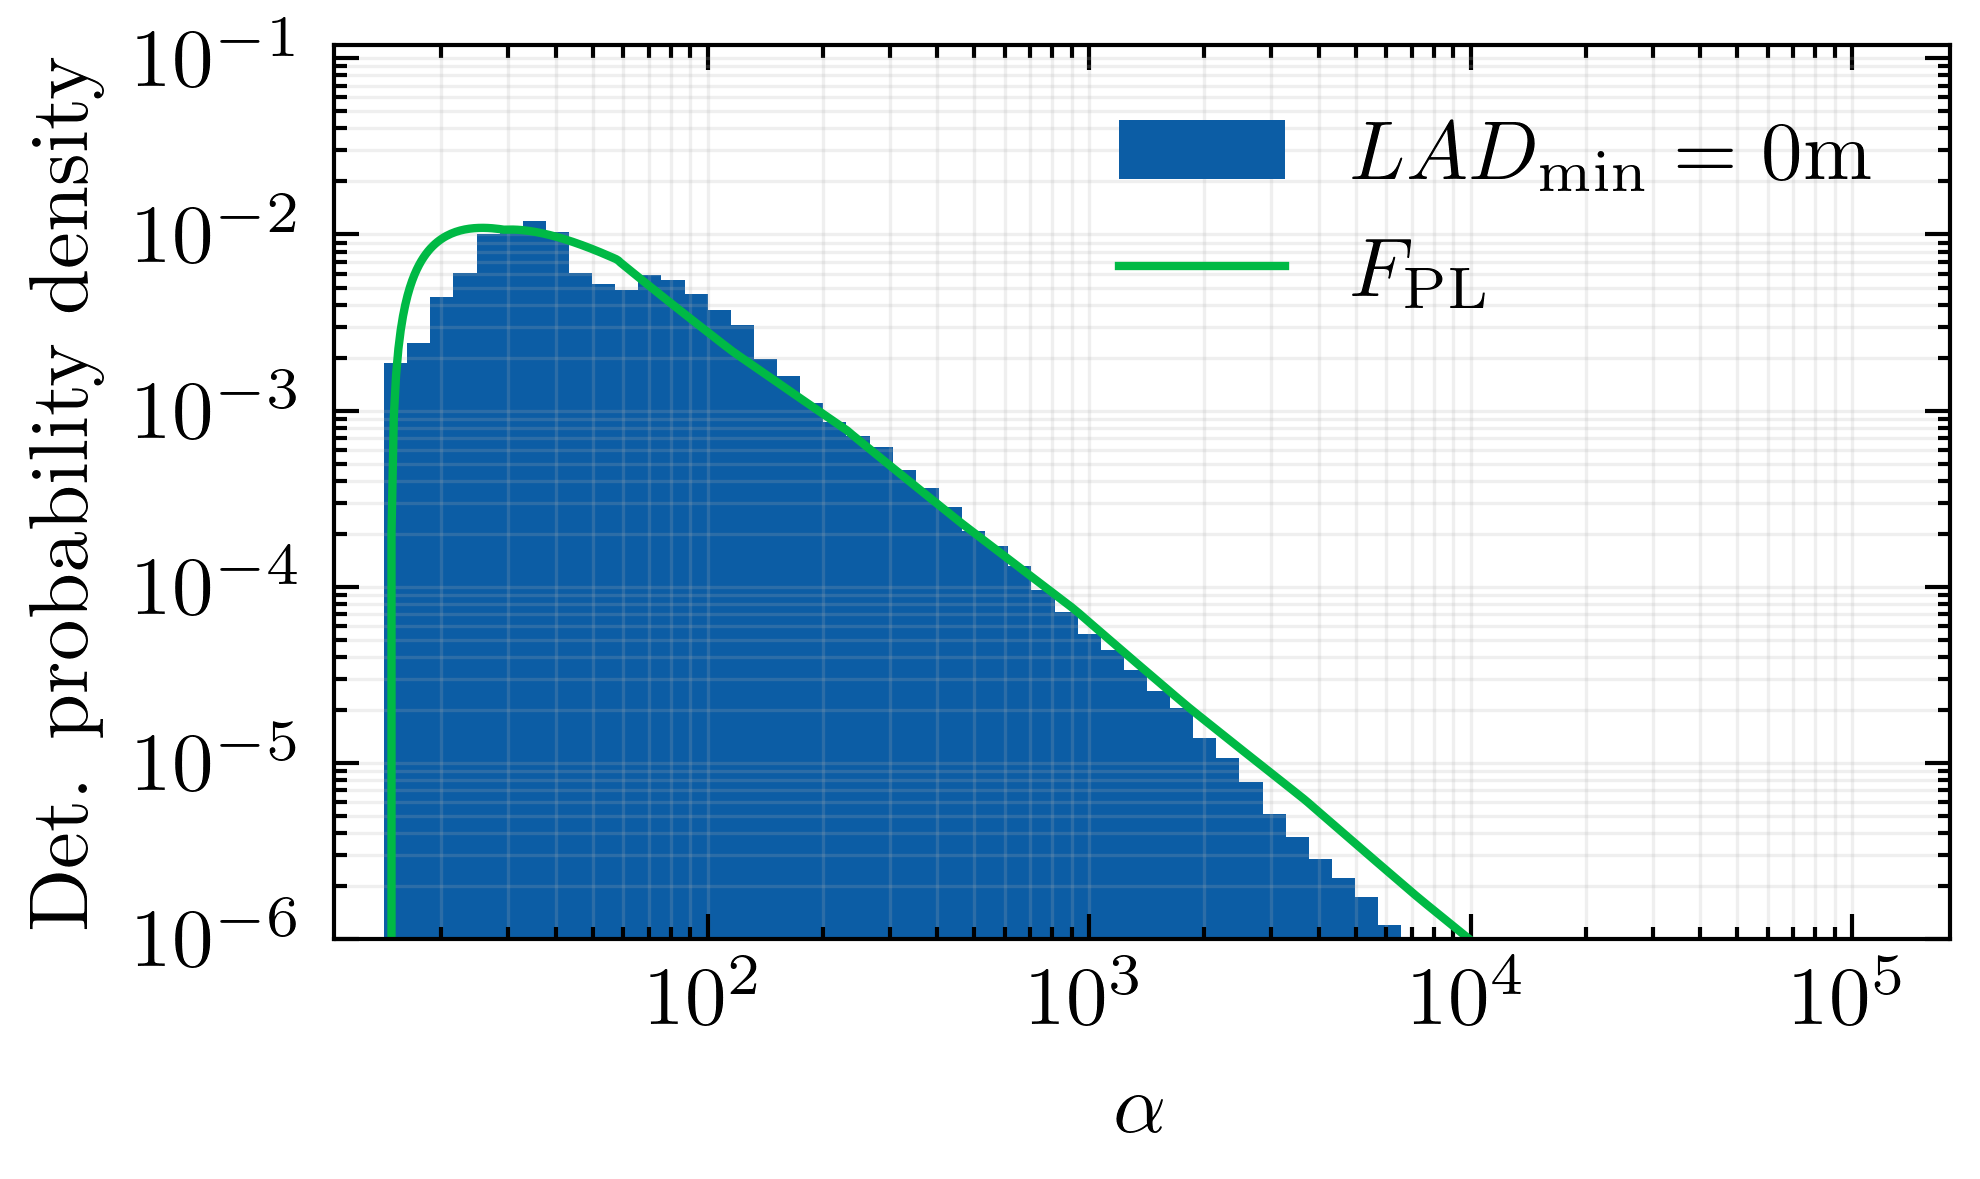

In [4]:
# 1.6290 0.6006 for LAD min = 2
alphas_hist = np.geomspace(1, 1e6, 100)
alphas = np.geomspace(1, 1e6, 1000)

counts, bins, _ = plt.hist(fit.cleaned_data.collect()["alpha"].to_numpy(),
                           alphas_hist, density = True, label = rf"$LAD_{{\text{{min}}}} = {fit.LAD_min}$m")

fit_params = PowerLawFitParams(*mle_model.params)
# fit_params = PowerLawFitParams(q=1, g=1.8)
plt.plot(alphas, fit.F_norm(alphas, fit_params, sm.best_p_function), label = r"$F_{\text{PL}}$")

plt.ylim(1e-6, counts.max() * 10)
plt.xlim(fit.plot_range[0] * 0.7, fit.plot_range[1] * 0.5)
plt.xscale("log")
plt.xlabel(r"$\alpha$")
plt.yscale("log")
plt.ylabel("Det. probability density")
plt.legend()
plt.grid(which='both', linestyle='-', linewidth=0.4, alpha=0.2)
plt.tight_layout()
# plt.savefig(f".plots/PL_fit_LAS_gt_{fit.LAD_min}m.png")
plt.show()

In [ ]:
from datetime import datetime

output_dir = Path("MLE_random_sample_fit_data/PowerLaw")

while True:
    df = fit.MultiMLEFit(
        optimize_params=PowerLawFitParams(q=1.63, g=1.8),
        numb_runs=20,
        summary = False
    )

    # Filename based on current datetime (to the second)
    timestamp: str = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    filename: Path = output_dir / f"{timestamp}.parquet"

    df.write_parquet(filename)

    print(f"Saved {filename}")

MultiMLE fit running:   0%|          | 0/20 [00:00<?, ?it/s]C:\Users\Joshu\OneDrive - Nexus365\AO33\Boulder_database\AO33\src\boulder_statistics\analysis\quick_calculate_general.py:149: RuntimeWarning: divide by zero encountered in log
  return np.log(F_norm(alphas, optimize_params, s_model))


Optimization terminated successfully.
         Current function value: 6.180993
         Iterations: 50
         Function evaluations: 99


MultiMLE fit running:   5%|▌         | 1/20 [00:27<08:35, 27.15s/it]C:\Users\Joshu\OneDrive - Nexus365\AO33\Boulder_database\AO33\src\boulder_statistics\analysis\quick_calculate_PowerLaw.py:48: RuntimeWarning: divide by zero encountered in divide
  log_max = np.log(alphas[:, None] / self.a_min)
C:\Users\Joshu\OneDrive - Nexus365\AO33\Boulder_database\AO33\src\boulder_statistics\analysis\quick_calculate_general.py:92: RuntimeWarning: divide by zero encountered in log
  np.log(total_p_alpha_sample),
C:\Users\Joshu\OneDrive - Nexus365\AO33\Boulder_database\AO33\src\boulder_statistics\analysis\quick_calculate_general.py:149: RuntimeWarning: divide by zero encountered in log
  return np.log(F_norm(alphas, optimize_params, s_model))


Optimization terminated successfully.
         Current function value: 6.196853
         Iterations: 59
         Function evaluations: 115


MultiMLE fit running:  10%|█         | 2/20 [00:59<09:06, 30.36s/it]C:\Users\Joshu\OneDrive - Nexus365\AO33\Boulder_database\AO33\src\boulder_statistics\analysis\quick_calculate_PowerLaw.py:48: RuntimeWarning: divide by zero encountered in divide
  log_max = np.log(alphas[:, None] / self.a_min)
C:\Users\Joshu\OneDrive - Nexus365\AO33\Boulder_database\AO33\src\boulder_statistics\analysis\quick_calculate_general.py:92: RuntimeWarning: divide by zero encountered in log
  np.log(total_p_alpha_sample),
C:\Users\Joshu\OneDrive - Nexus365\AO33\Boulder_database\AO33\src\boulder_statistics\analysis\quick_calculate_general.py:149: RuntimeWarning: divide by zero encountered in log
  return np.log(F_norm(alphas, optimize_params, s_model))


...

MultiMLE fit running:  95%|█████████▌| 19/20 [54:53<00:30, 30.55s/it]C:\Users\Joshu\OneDrive - Nexus365\AO33\Boulder_database\AO33\src\boulder_statistics\analysis\quick_calculate_PowerLaw.py:48: RuntimeWarning: divide by zero encountered in divide
  log_max = np.log(alphas[:, None] / self.a_min)
C:\Users\Joshu\OneDrive - Nexus365\AO33\Boulder_database\AO33\src\boulder_statistics\analysis\quick_calculate_general.py:92: RuntimeWarning: divide by zero encountered in log
  np.log(total_p_alpha_sample),
C:\Users\Joshu\OneDrive - Nexus365\AO33\Boulder_database\AO33\src\boulder_statistics\analysis\quick_calculate_general.py:149: RuntimeWarning: divide by zero encountered in log
  return np.log(F_norm(alphas, optimize_params, s_model))


Optimization terminated successfully.
         Current function value: 6.180585
         Iterations: 52
         Function evaluations: 102


MultiMLE fit running: 100%|██████████| 20/20 [55:16<00:00, 165.85s/it]


Saved MLE_random_sample_fit_data\PowerLaw\2026-06-30_13-16-58.parquet


MultiMLE fit running:   0%|          | 0/20 [00:00<?, ?it/s]C:\Users\Joshu\OneDrive - Nexus365\AO33\Boulder_database\AO33\src\boulder_statistics\analysis\quick_calculate_PowerLaw.py:48: RuntimeWarning: divide by zero encountered in divide
  log_max = np.log(alphas[:, None] / self.a_min)
C:\Users\Joshu\OneDrive - Nexus365\AO33\Boulder_database\AO33\src\boulder_statistics\analysis\quick_calculate_general.py:92: RuntimeWarning: divide by zero encountered in log
  np.log(total_p_alpha_sample),
C:\Users\Joshu\OneDrive - Nexus365\AO33\Boulder_database\AO33\src\boulder_statistics\analysis\quick_calculate_general.py:149: RuntimeWarning: divide by zero encountered in log
  return np.log(F_norm(alphas, optimize_params, s_model))
